In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

import pandas as pd

from scipy import stats

Here's the math that forms the basis for this propagation of covariance matrices I'm doing here:

Given four random scalars $A, B, C, D$ where $(A,C)$ are independent of $(B,D)$:

\begin{align*}
    \text{Cov}(AB, CD) &= \langle ABCD \rangle - \langle AB \rangle \langle CD \rangle \\
    &= \langle AC \rangle \langle BD \rangle - \langle A \rangle \langle B \rangle \langle C \rangle \langle D \rangle \\
    &= (\text{Cov}(A,C) + \langle A \rangle \langle C \rangle)(\text{Cov}(B,D) + \langle B \rangle \langle D \rangle) - \langle A \rangle \langle B \rangle \langle C \rangle \langle D \rangle \\
    &= \langle A \rangle \text{Cov}(B,D) \langle C \rangle + \langle B \rangle \text{Cov}(A,C) \langle D \rangle + \text{Cov}(A, C)\text{Cov}(B,D)
\end{align*}

Derivation source (https://stats.stackexchange.com/questions/420032/proof-verification-joint-variance-of-the-product-of-a-random-matrix-with-a-rand)

Now given two random *vectors* of equal size $\vec{x}, \vec{y}$, with expected values $\hat{x}, \hat{y}$ and covariance matrices $X, Y$, we can say:

\begin{align*}
    \text{Cov}(x_iy_i, x_jy_j) &= \hat{x}_i Y_{ij} \hat{x}_j + \hat{y}_i X_{ij} \hat{y}_j + X_{ij}Y_{ij}
\end{align*}

Which defines the covariance matrix of the element-wise product of our two vectors.

The covariance matrix of the inner product is then:

\begin{align*}
    \text{Cov}(\vec{x}\cdot\vec{y}) &= \sum_{ij} \hat{x}_i Y_{ij} \hat{x}_j + \hat{y}_i X_{ij} \hat{y}_j + X_{ij}Y_{ij}\\
    &= \hat{x}Y\hat{x} + \hat{y}X \hat{y} + \sum_{ij} X_{ij}Y_{ij}
\end{align*}

Now let's define the actual calculation.

Let $c_{ij}$ be a predicted $^{14}C$ profile with index $i$ selecting between 'fast' or 'neg' production, and $j$ the sample depth.

The distribution of all $^{14}C$ predictions has an average of $\hat{c}_{ij}$ and a covariance matrix of $C_{ijkl}$.

Next, let $f_i$ be a pair of production scaling factors, where the average is $\hat{f}_i$ and covariance matrix is $F_{ij}$.

The distribution of $^{14}CO$ predicted by this model would have the following mean and covariance matrix:
$$\hat{co}_i = \hat{f}_{j} \hat{c}_{ji}; \qquad CO_{ij} = \hat{c}_{ki}F_{kl}\hat{c}_{lj} + \hat{f}_k C_{kilj} \hat{f}_l + C_{kilj} F_{ij}$$

Our final step is to apply a relative systematic error to our prediction.

We define a vector $s_i$ with length equal to the number of samples, taken from a normal distribution centered on $\vec{0}$ with 2% standard deviation independent along each index.

The covariance matrix $S_{ij}$ is diagonal with elements equal to $0.02^2$.

The mean and covariance of our final predicted distribution are:
$$\hat{co}_{\text{samp }i} = (1+\hat{s}_i) \hat{co}_i; \qquad CO_{\text{samp }ij} = CO_{ij} + \hat{co}_i S_{ij} \hat{co}_j + CO_{ij}S_{ij}$$

In [2]:
Prop = Propagator(elev=0)
Prop.set_H(0) #sets atmospheric depth to sea level (for calculations which use hg/cm^2)

In [3]:
Prop.load_ice_profile('Real_vs_ice_eq_depth.csv', 'DomeC_age_scale_Apr2023.csv')

In [4]:
Prop.set_energy_bins(logE_min = -1, logE_max = 11, logE_mu_max=7.5, dlogE=0.1)

In [5]:
Prop.set_zenith_bins(N_ang=10)

In [6]:
df_Pfast = pd.read_csv('Production Rates/P_fast_0m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_0m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [7]:
Prop.Phi['prod']=P_14C
C_pred = F.flow_14C(Prop)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [00:26<00:00, 272.67it/s]


In [8]:
np.shape(C_pred)

(161, 2, 7283)

In [10]:
C_weights = np.ones(len(C_pred))

In [19]:
df = pd.read_csv('14CO_f_all_ChiSq.csv')
f_factors = np.array([df['fast'],df['f_neg']]).T
f_weights = np.array(np.exp(-df['Chi_sq']/2)) # convert chi^2 to prior weight

In [26]:
Prop.Phi['prod']

array([[[6.33806022e-01, 5.73169598e-01, 4.74521976e-01, ...,
         5.10443077e-01, 5.10460383e-01, 7.42373942e-01],
        [1.52495426e-04, 3.52278799e+00, 1.96146659e+00, ...,
         1.77453393e+00, 1.77456635e+00, 4.76786220e+00]],

       [[6.32696499e-01, 5.71989438e-01, 4.73585746e-01, ...,
         5.09385451e-01, 5.09402737e-01, 7.40711036e-01],
        [2.42000047e-03, 3.54466042e+00, 1.98572499e+00, ...,
         1.82882735e+00, 1.82886062e+00, 4.75608391e+00]],

       [[6.31584049e-01, 5.70805674e-01, 4.72646128e-01, ...,
         5.08325630e-01, 5.08342896e-01, 7.39073420e-01],
        [1.20694012e-02, 3.61757220e+00, 2.09995912e+00, ...,
         1.87683686e+00, 1.87687087e+00, 4.74426599e+00]],

       ...,

       [[1.49600644e-02, 1.67164058e-02, 1.28123514e-02, ...,
         1.01177381e-02, 1.01195284e-02, 2.00421675e-02],
        [2.68929511e-03, 2.62602748e-03, 2.11101602e-03, ...,
         1.68218600e-03, 1.68232212e-03, 3.50842211e-03]],

       [[1.49572862

In [20]:
#C_pred = np.array([
    #[
        #[1., 2., 3., 4.,],
        #[0.5, 1.5, 2.5, 3.5],
    #],
    #[
        #[0.5, 1.5, 2.5, 3.5],
        #[0.4, 1.2, 2.3, 3.],
    #],
    #[
        #[1., 1.9, 3.4, 4.5],
        #[0.9, 1.2, 2.2, 3.6],
    #],
#])
# axis0 - Model
# axis1 - Production Mode
# axis2 - Sample Depth

#C_weights = np.ones(len(C_pred))
# axis0 - Model

C_avg = np.average(C_pred, weights=C_weights, axis=0)
# axis0 - Production Mode
# axis1 - Sample Depth

C_cov = np.reshape(
    np.cov(np.reshape(C_pred, (len(C_pred), -1)), rowvar=False, aweights=C_weights),
    (*np.shape(C_avg), *np.shape(C_avg)))
# axis0 - Production Mode A
# axis1 - Sample Depth A
# axis2 - Production Mode B
# axis3 - Sample Depth B

#f_factors = np.array([
    #[0.1, 0.06],
    #[0.08, 0.08],
    #[0.1, 0.07],
    #[0.09, 0.06],
    #[0.11, 0.09],
    #[0.06, 0.08],
#])
# axis0 - f_factor
# axis1 - Production Mode

#f_weights = np.ones(len(f_factors))
# axis0 - f_factor

f_avg = np.average(f_factors, weights=f_weights, axis=0)
# axis0 - Production Mode

f_cov = np.cov(f_factors, rowvar=False, aweights=f_weights)
# axis0 - Production Mode A
# axis1 - Production Mode B

CO_avg = f_avg @ C_avg
# axis0 - Sample Depth

CO_cov = f_avg @ np.moveaxis(C_cov, (0,2), (-2,-1)) @ f_avg + C_avg.T @ f_cov @ C_avg + np.sum(C_cov * np.reshape(f_cov, (2,1,2,1)), axis=(0,2))
# axis0 - Sample Depth A
# axis1 - Sample Depth B

rel_err = 0.02 * np.ones(len(CO_avg))
# axis0 - Sample Depth

s_cov = np.diag(rel_err**2)
# axis0 - Sample Depth A
# axis1 - Sample Depth B

CO_samp_cov = CO_cov + CO_avg * s_cov * CO_avg.T + CO_cov * s_cov
# axis0 - Sample Depth A
# axis1 - Sample Depth B

CO_samp_cov_inv = np.linalg.inv(CO_samp_cov)

LinAlgError: Singular matrix

In [22]:
C_pred

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [4]:
CO_samp_cov

array([[0.00200786, 0.00149457, 0.00254481, 0.00409608],
       [0.00149457, 0.00236842, 0.00306217, 0.0041996 ],
       [0.00254481, 0.00306217, 0.00501644, 0.0072125 ],
       [0.00409608, 0.0041996 , 0.0072125 , 0.01104526]])

In [5]:
CO_avg

array([0.119     , 0.25733333, 0.43811111, 0.60688889])

In [26]:
x = np.random.multivariate_normal(CO_avg, CO_samp_cov)
print(x)

[0.07076986 0.25299234 0.42379399 0.61409682]


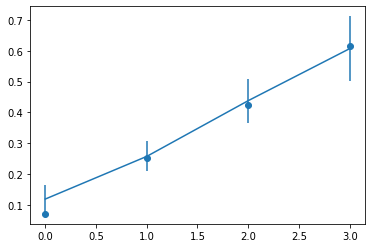

In [34]:
plt.errorbar(np.arange(4), CO_avg, yerr=np.sqrt(np.diag(CO_samp_cov)))
plt.scatter(np.arange(4), x)

In [28]:
# calculate chi^2 value
chi2 = (x-CO_avg).T @ CO_samp_cov_inv @ (x-CO_avg)
print(chi2)

10.399896135003065


In [29]:
# calculate p-value
p = 1-stats.chi2.cdf(chi2, len(x))
print(p)

0.03420418918262247


In [30]:
# calculate standard deviations
sig = stats.norm.isf(p/2.)
print(sig)

2.117656266724403


With the expected value and covariance matrix calculated for our constant flux model, we can evaluate the $\chi^2$ and $\sigma$ values of sample data.

In addition, we can evaluate the sensitivity of our analysis to various types of non-constant flux.

Let $\vec{c}_{\text{var}}$ be the variation in the observed $^{14}$CO levels that results from a non-constant flux.  Because the conversion from flux over time to observed $^{14}$CO is a linear transformation, we can express the total $^{14}$CO produced by a time-dependent flux as:

$$\vec{c}_{\text{obs}} = \vec{c}_{\text{const}} + a\vec{c}_{\text{var}}$$

Where $a$ is the amplitude of our non-constant variation.

If we assume that $\hat{c}_{\text{const}}$ is both the mean and median of our constant distribution, then given a median value $\hat{c}_{\text{var}}$ of $\vec{c}_{\text{var}}$, the median observed $^{14}$CO distribution would be:

$$\hat{c}_{\text{obs}} = \hat{c}_{\text{const}} + a\hat{c}_{\text{var}}$$

And the $\chi^2$ of the median is then:

\begin{align*}
    \hat{\chi}^2 &= (\hat{c}_{\text{obs}}-\hat{c}_{\text{const}})CO_{\text{samp}}^{-1}(\hat{c}_{\text{obs}}-\hat{c}_{\text{const}})\\
    &= (a\hat{c}_{\text{var}})CO_{\text{samp}}^{-1}(a\hat{c}_{\text{var}})\\
    &= a^2 \hat{c}_{\text{var}}CO_{\text{samp}}^{-1}\hat{c}_{\text{var}}
\end{align*}

If we define the sensitivity of our analysis to a variation $\vec{c}_{\text{var}}$ to be the amplitude $a$ such that $\chi^2 \geq \chi^2_{\text{thresh}}$ in 50% of cases, where $\chi^2_{\text{thresh}}$ corresponds to a desired p-value or $\sigma$ value, then we can approximate:
$$a(\chi^2_{\text{thresh}}) \approx \sqrt{\frac{\chi^2_{\text{thresh}}}{\hat{c}_{\text{var}}CO_{\text{samp}}^{-1}\hat{c}_{\text{var}}}}$$

Where we approximate that for a distribution with its median on the surface of an N-dimensional ellipse, 50% of the distribution falls inside the ellipse ($\chi^2<\chi^2_{\text{thresh}}$), and 50% falls outside ($\chi^2>\chi^2_{\text{thresh}}$).  In reality, >50% would fall outside, as the ellipse has positive curvature.

This means our sensitivity $a$ is actually slightly smaller, by a factor which could be calculated by integrating the probability distribution of $\vec{c}_{\text{const}} + a\vec{c}_{\text{var}}$ bound within the N-dimensional surface about $\hat{c}_{\text{const}}$ where $\chi^2 = \chi^2_{\text{thresh}}$.  But I think I can live with a slight over-estimate.

NOTE: This definition of sensitivity is identical to the Bayesian one we used previously, under the assumption our model uncertainties follow a multivariate normal distribution.

If we insist upon using Bayes factors to analyze our data and don't want to make a gaussian approximation, we can use our model weights as priors and calculate:

$$P(\vec{c}|H) = \int d\vec{\theta}P(\vec{\theta}|H) \frac{1}{\sqrt{|2\pi\Sigma|}} \exp(-\frac{1}{2}(\vec{c}-\hat{c}(\vec{\theta},H))^T\Sigma^{-1}(\vec{c}-\hat{c}(\vec{\theta},H)))$$

Where $\vec{c}$ is our data, $H$ is the model, $\vec{\theta}$ is the model parameters, and $\Sigma$ is the covariance matrix of the systematic uncertainty (which should be diagonal).

The Bayes factor between a time-dependent model $H_1$ and our null model $H_0$ is then:
$$B_{10} = \frac{P(\vec{c}|H_1)}{P(\vec{c}|H_0)} = \frac{\int d\vec{\theta}P(\vec{\theta}|H_1) \exp(-\frac{1}{2}(\vec{c}-\hat{c}(\vec{\theta},H_1))^T\Sigma^{-1}(\vec{c}-\hat{c}(\vec{\theta},H_1)))}{\int d\vec{\theta}P(\vec{\theta}|H_0) \exp(-\frac{1}{2}(\vec{c}-\hat{c}(\vec{\theta},H_0))^T\Sigma^{-1}(\vec{c}-\hat{c}(\vec{\theta},H_0)))}$$



Let's start expanding out $\vec{\theta}$ into some specific parameters of our calculation.  We'll start by pulling out the amplitude $a$ of our time-dependent model.  Our integral is now:
$$P(\vec{c}|H_1) = \int d\vec{\theta}\,da\,P(a|H_1)P(\vec{\theta}|H_1)\frac{1}{\sqrt{|2\pi\Sigma|}} \exp(-\frac{1}{2}(\vec{c}-\hat{c}(\vec{\theta},H_0)-a\hat{c}(\vec{\theta},H_1))^T\Sigma^{-1}(\vec{c}-\hat{c}(\vec{\theta},H_0)-a\hat{c}(\vec{\theta},H_1)))$$

Let $\vec{c}_\perp$ be the component of $\vec{c}-\hat{c}_0$ which is orthogonal to $\hat{c}_1$ in the basis where $\Sigma=I$ (AKA the best fit varying $a$), and let $a' = \frac{\vec{c}-\hat{c}_0-\vec{c}_\perp}{|\hat{c}_1|}+a$.  We'll make $a'$ our new integration variable and our calculation becomes:
\begin{align*}
    P(\vec{c}|H_1) &= \int d\vec{\theta}\,da'\,P(a'|H_1)P(\vec{\theta}|H_1)\frac{1}{\sqrt{|2\pi\Sigma|}} \exp(-\frac{1}{2}(\vec{c}_\perp-a'\hat{c}_1)^T\Sigma^{-1}(\vec{c}_\perp-a'\hat{c}_1))\\
    &= \int d\vec{\theta} P(\vec{\theta}|H_1) \int da'\,P(a'|H_1)\frac{1}{\sqrt{|2\pi\Sigma|}} \exp(-\frac{\vec{c}_\perp^T\Sigma^{-1}\vec{c}_\perp}{2}-\frac{a'^2}{2}\hat{c}_1^T\Sigma^{-1}\hat{c}_1)\\
\end{align*}

As we can see, the integral over $a'$ is a one-dimensional non-normalized gaussian.  If our prior $P(a'|H_1)$ is constant over the integration range, then this layer of the integral can be simplified to something involving the error function, which python has implementations.  One would expect these to be much faster and more precise than numerical integration.

\begin{align*}
P(\vec{c}|H_1) &= \int d\vec{\theta} P(\vec{\theta}|H_1) \frac{1}{\sqrt{|2\pi\Sigma|}} \exp(-\frac{\vec{c}_\perp^T\Sigma^{-1}\vec{c}_\perp}{2}) \frac{1}{a'_1-a'_0}\int_{a'_0}^{a'_1} da'\, \exp(-\frac{a'^2}{2}\hat{c}_1^T\Sigma^{-1}\hat{c}_1)\\
&= \int d\vec{\theta} P(\vec{\theta}|H_1) \frac{1}{\sqrt{|2\pi\Sigma|}} \exp(-\frac{\vec{c}_\perp^T\Sigma^{-1}\vec{c}_\perp}{2}) \frac{1}{a'_1-a'_0} \frac{\sqrt{\pi}(\text{erf}(a'_1\sqrt{\frac{\hat{c}_1^T\Sigma^{-1}\hat{c}_1}{2}})-\text{erf}(a'_0\sqrt{\frac{\hat{c}_1^T\Sigma^{-1}\hat{c}_1}{2}}))}{\sqrt{2\hat{c}_1^T\Sigma^{-1}\hat{c}_1}}\\
\end{align*}

And just to make our lives easier, how about we go ahead and make $a'' = a'\sqrt{\frac{\hat{c}_1^T\Sigma^{-1}\hat{c}_1}{2}}$,
$$P(\vec{c}|H_1) = \int d\vec{\theta} P(\vec{\theta}|H_1) \frac{1}{\sqrt{|2\pi\Sigma|}} \exp(-\frac{\vec{c}_\perp^T\Sigma^{-1}\vec{c}_\perp}{2}) \frac{\sqrt{\pi}(\text{erf}(a''_1)-\text{erf}(a''_0))}{2(a''_1-a''_0)}$$

Pulling out our f-factors next, if we wanted, we could assume our f-factors have a gaussian distribution and retroactively incorporate the covariance into $\Sigma$ to remove that integration step entirely.
$$P(\vec{c}|H_1) = \int d\vec{\theta} P(\vec{\theta}|H_1) \frac{1}{\sqrt{|2\pi\Sigma_f|}} \exp(-\frac{\vec{c}_\perp^T\Sigma_f^{-1}\vec{c}_\perp}{2}) \frac{\sqrt{\pi}(\text{erf}(a''_1)-\text{erf}(a''_0))}{2(a''_1-a''_0)}$$

The only remaining parameters are the various models used to propagate our muons.  Since these are discrete, the only way to integrate them is by summing over all the values:

$$P(\vec{c}|H_1) = \sum_{\vec{\theta}} P(\vec{\theta}|H_1) \frac{1}{\sqrt{|2\pi\Sigma_f|}} \exp(-\frac{\vec{c}_\perp^T\Sigma_f^{-1}\vec{c}_\perp}{2}) \frac{\sqrt{\pi}(\text{erf}(a''_1)-\text{erf}(a''_0))}{2(a''_1-a''_0)}$$

If we suppose we would have used $\sim10$ bins of $a$ and $\sim20$ bins of $\vec{f}$, this method requires 200x fewer iterations than the brute force method we started with!  The downside is that $a''$, $\vec{c}_\perp$, and $\Sigma_f$ have to be calculated for each remaining parameterization, where before they were constant across all.

Going back, now we need to get formulas for $\vec{c}_\perp$ and $\Sigma_f$.

Starting with $\Sigma_f$, our goal is to get the covariance matrix of the vector:
$$c_{\text{tot }i} = f_j c_{ji} s_i$$

For $c_{ji}$ under a fixed parameterization $\vec{\theta}$ of model $H$.

Taking the calculation we did previously, but setting the covariance matrix $C_{ijkl}$ to 0, we get:

\begin{align*}
    CO_{ij} &= \hat{c}_{ik}F_{kl}\hat{c}_{lj}\\
    \Sigma_{\text{f }ij} &= CO_{ij} + \hat{co}_i S_{ij} \hat{co}_j + CO_{ij}S_{ij}\\
    &= \hat{c}_{ik}F_{kl}\hat{c}_{lj} + \hat{f}_k\hat{c}_{ki} S_{ij} \hat{f}_l\hat{c}_{lj} + \hat{c}_{ik}F_{kl}\hat{c}_{lj}S_{ij}\\
    &= \hat{c}_{ik}F_{kl}\hat{c}_{lj}(1+S_{ij}) + \hat{c}_{ik}\hat{f}_k \hat{f}_l\hat{c}_{lj} S_{ij}
\end{align*}

Now we need to transform $\vec{c}-\hat{c}_0$ to the basis where $\Sigma_f = I$ (I know this is poor notation).  Look, maybe I don't mean a change of basis.  I just mean we apply a transformation $T$ to $\vec{c}-\hat{c}_0$ such that $\vec{c}' = T(\vec{c}-\hat{c}_0)$ and $\vec{c}'^T\vec{c}' = (\vec{c}-\hat{c}_0)^T \Sigma_f^{-1} (\vec{c}-\hat{c}_0)$.  That is,
$$\Sigma_f^{-1} = S \Lambda^{-1} S^{-1} = T^T T$$

Now look, I *know* $T = \lambda^{-1/2}S^{-1} = \lambda^{-1/2}S^T$; this follows because $\Sigma_f$ is a covariance matrix, and therefore symmetric, and the eigenvectors of a covariance matrix are orthonormal.  Then,

\begin{align*}
    \vec{c}' &= \Lambda^{-1/2}S^T(\vec{c}-\hat{c}_0)\\
    \vec{c}_\perp &= S\Lambda^{1/2}[\vec{c}'-\frac{\vec{c}'^T\Lambda^{-1/2}S^T\hat{c}_1}{|\Lambda^{-1/2}S^T\hat{c}_1|^2}\Lambda^{-1/2}S^T\hat{c}_1]\\
    &= \vec{c}-\hat{c}_0 - \frac{(\vec{c}-\hat{c}_0)^TS\Lambda^{-1/2}\Lambda^{-1/2}S^T\hat{c}_1}{|\Lambda^{-1/2}S^T\hat{c}_1|^2}\hat{c}_1\\
    &= \vec{c}-\hat{c}_0 - \frac{(\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1}{\hat{c}_1^T\Sigma_f^{-1}\hat{c}_1}\hat{c}_1\\
    a' &= a + \frac{(\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1}{\hat{c}_1^T\Sigma_f^{-1}\hat{c}_1}\\
    a'' &= (a + \frac{(\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1}{\hat{c}_1^T\Sigma_f^{-1}\hat{c}_1})\sqrt{\frac{\hat{c}_1^T\Sigma_f^{-1}\hat{c}_1}{2}}\\
    &= (a + \frac{\chi^2_{01}}{\chi^2_{11}})\sqrt{\frac{\chi^2_{11}}{2}}\\
    \vec{c}_\perp^T\Sigma_f^{-1}\vec{c}_\perp &= (\vec{c}-\hat{c}_0 - \frac{(\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1}{\hat{c}_1^T\Sigma_f^{-1}\hat{c}_1}\hat{c}_1)^T \Sigma_f^{-1} (\vec{c}-\hat{c}_0 - \frac{(\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1}{\hat{c}_1^T\Sigma_f^{-1}\hat{c}_1}\hat{c}_1)\\
    &= (\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}(\vec{c}-\hat{c}_0) - 2\frac{((\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1)^2}{\hat{c}_1^T\Sigma^{-1}\hat{c}_1} + \frac{((\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1)^2}{\hat{c}_1^T\Sigma^{-1}\hat{c}_1}\\
    &= (\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}(\vec{c}-\hat{c}_0) - \frac{((\vec{c}-\hat{c}_0)^T\Sigma_f^{-1}\hat{c}_1)^2}{\hat{c}_1^T\Sigma_f^{-1}\hat{c}_1}\\
    &= \chi^2_{00}-\frac{(\chi^2_{01})^2}{\chi^2_{11}}\\
    &= \chi^2_{\text{min}}
\end{align*}

Wait, frick, $\Sigma_f$ depends on $a$!

\begin{align*}
    \Sigma_{\text{f }ij} &= \hat{c}_{ik}F_{kl}\hat{c}_{lj}(1+S_{ij}) + \hat{c}_{ik}\hat{f}_k \hat{f}_l\hat{c}_{lj} S_{ij}\\
    &= \hat{c}_{ik}(F_{kl}(1+S_{ij}) + \hat{f}_k \hat{f}_l S_{ij})\hat{c}_{lj}\\
    &= (\hat{c}_0+a\hat{c}_1)_{ik}(F_{kl}(1+S_{ij}) + \hat{f}_k \hat{f}_l S_{ij})(\hat{c}_0+a\hat{c}_1)_{lj}\\
    &= \Sigma_{00} + a\Sigma_{01} + a^2\Sigma_{11}
\end{align*}

In [9]:
Sigma_f = C_avg.T @ f_cov @ C_avg + (f_avg@C_avg).T * s_cov * (f_avg@C_avg) + C_avg.T @ f_cov @ C_avg * s_cov
#L = np.sum(C_weights*/np.sqrt(np.linalg.det(2*np.pi*Sigma_f))*np.exp(), )

In [10]:
Sigma_f

array([[0.00026079, 0.00055113, 0.00092196, 0.00125882],
       [0.00055113, 0.00121803, 0.00199256, 0.00272071],
       [0.00092196, 0.00199256, 0.0034161 , 0.00456306],
       [0.00125882, 0.00272071, 0.00456306, 0.00639354]])